# Garbage Reports — Forecasting Model Tests

This notebook is intentionally focused on **model evaluation**, not exploratory plots.

The default task is **rolling one-day-ahead forecasting**:
- when forecasting day *t*, values from earlier days are assumed to be known;
- lagged predictors therefore use only past observations;
- evaluation uses expanding training windows and future test years.

The current benchmark is to improve on simple baselines while keeping performance stable across years.


In [32]:
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.graphics.tsaplots import plot_acf

from scipy.stats import chi2
from sklearn.metrics import mean_absolute_error, mean_squared_error

from src.calendar_features import add_greek_holiday_features

## 1. Data configuration and preparation

In [33]:
PATH = r"data/requests.csv"

ISSUE_TYPE = "garbage"
START_YEAR = 2020
END_YEAR = 2025

df = pd.read_csv(PATH)
df["reported"] = pd.to_datetime(df["reported"], errors="coerce")

df = (
    df.loc[
        (df["issue"] == ISSUE_TYPE)
        & (df["reported"].dt.year >= START_YEAR)
        & (df["reported"].dt.year <= END_YEAR)
    ]
    .dropna(subset=["reported"])
    .sort_values("reported")
    .copy()
)

daily_counts = (
    df.set_index("reported")
      .resample("D")
      .size()
)

daily_df = daily_counts.reset_index(name="reports")
daily_df["weekday"] = daily_df["reported"].dt.day_name()
daily_df["month"] = daily_df["reported"].dt.month
daily_df = add_greek_holiday_features(daily_df, "reported")

# Scale the time trend to years rather than raw day numbers.
# This is numerically friendlier for the Negative Binomial optimizer.
daily_df["trend_years"] = (
    (daily_df["reported"] - daily_df["reported"].min()).dt.days / 365.25
)

# Lag / recent-history features.
# Every feature is shifted, so today's report count is never used to predict today.
daily_df["lag1"] = daily_df["reports"].shift(1)
daily_df["lag7"] = daily_df["reports"].shift(7)
daily_df["recent3_avg"] = daily_df["reports"].shift(1).rolling(3).mean()
daily_df["rolling7_avg"] = daily_df["reports"].shift(1).rolling(7).mean()
daily_df["same_weekday_4wk_avg"] = (
    daily_df["reports"].shift(7)
    + daily_df["reports"].shift(14)
    + daily_df["reports"].shift(21)
    + daily_df["reports"].shift(28)
) / 4

print(f"Daily observations: {len(daily_df):,}")
print(f"Date range: {daily_df['reported'].min().date()} -> {daily_df['reported'].max().date()}")

Daily observations: 2,191
Date range: 2020-01-02 -> 2025-12-31


## 2. Poisson overdispersion check

The raw variance/mean ratio is only a rough first look. The more relevant check is whether overdispersion remains **after** trend, weekday and month are included.

A Pearson dispersion substantially above 1 supports using Negative Binomial rather than ordinary Poisson regression.


In [34]:
poisson_train = daily_df[daily_df["reported"].dt.year <= 2024].copy()

poisson_model = smf.glm(
    "reports ~ trend_years + C(weekday) + C(month)",
    data=poisson_train,
    family=sm.families.Poisson()
).fit()

raw_mean = poisson_train["reports"].mean()
raw_var = poisson_train["reports"].var()

pearson_dispersion = poisson_model.pearson_chi2 / poisson_model.df_resid
deviance_dispersion = poisson_model.deviance / poisson_model.df_resid
pearson_p = chi2.sf(poisson_model.pearson_chi2, poisson_model.df_resid)

print(f"Raw mean:                 {raw_mean:.3f}")
print(f"Raw variance:             {raw_var:.3f}")
print(f"Raw variance / mean:      {raw_var / raw_mean:.3f}")
print()
print(f"Pearson dispersion:       {pearson_dispersion:.3f}")
print(f"Deviance / df:            {deviance_dispersion:.3f}")
print(f"Pearson dispersion p-val: {pearson_p:.3e}")

Raw mean:                 19.674
Raw variance:             161.635
Raw variance / mean:      8.216

Pearson dispersion:       3.122
Deviance / df:            3.368
Pearson dispersion p-val: 0.000e+00


## 3. Choose what to test

Set `MODELS_TO_TEST` to a list and choose `HOLIDAY_MODE`, then rerun this cell plus the next one.

Values you can place inside `MODELS_TO_TEST`:

| Value to type | What it includes |
|---|---|
| `"all"` | Every baseline and every Negative Binomial model below |
| `"baselines"` | All five fixed-rule baselines |
| `"mean"` | Historical training-period mean |
| `"weekday_mean"` | Historical mean for the matching weekday |
| `"lag7"` | Actual report count from seven days earlier |
| `"rolling7"` | Average of the previous seven actual days |
| `"same_weekday_4wk"` | Average of the same weekday over the previous four weeks |
| `"nb_base"` | Trend + weekday + month |
| `"nb_lag1"` | Trend + weekday + month + previous day's actual count |
| `"nb_recent3"` | Trend + weekday + month + previous three-day average (**current control model**) |
| `"nb_lag1_lag7"` | Trend + weekday + month + lag 1 + lag 7 |
| `"nb_4wk"` | Trend + weekday + month + previous four same-weekday average |
| `"nb_quadratic"` | Linear and quadratic trend + weekday + month |
| `"nb_recent3_lag7"` | Trend + weekday + month + recent 3-day average + lag 7 |
| `"nb_recent3_lag7_no_weekday"` | Trend + month + recent 3-day average + lag 7 (**lag 7 replaces weekday**) |
| `"nb_recent3_lag7_no_weekday_no_trend"` | Month + recent 3-day average + lag 7 (**both weekday and trend removed**) |

Examples:

```python
# Test a selected group:
MODELS_TO_TEST = [
    "nb_recent3",
    "nb_recent3_lag7",
    "nb_recent3_lag7_no_weekday",
]

# Test everything:
MODELS_TO_TEST = ["all"]

# Test all baselines plus one NB model:
MODELS_TO_TEST = ["baselines", "nb_recent3"]
```

Holiday choices for Negative Binomial models:

- `"without"` — test without a holiday term.
- `"with"` — add `C(is_holiday)` to the selected model.
- `"both"` — test both versions side by side.

Simple baselines are shown once because they have no regression formula to which a holiday term can be added.

The test years use expanding windows:
- train through 2022 → test 2023
- train through 2023 → test 2024
- train through 2024 → test 2025


In [35]:
MODELS_TO_TEST = [
    "nb_recent3",
    "nb_recent3_lag7",
    "nb_recent3_lag7_no_weekday",
    "nb_recent3_lag7_no_weekday_no_trend",
]
HOLIDAY_MODE = "both"  # choose: "without", "with", or "both"

TEST_YEARS = [2023, 2024, 2025]

## 4. Run model tests

This is the main testing cell.  
After changing `MODELS_TO_TEST` above, rerun this cell.

For one Negative Binomial variant (a single model with `HOLIDAY_MODE` set to `"with"` or `"without"`), this cell also shows out-of-sample residual diagnostics.


In [36]:
# -----------------------------
# Model definitions
# -----------------------------

BASE_FORMULA = "reports ~ trend_years + C(weekday) + C(month)"

NB_FORMULAS = {
    "nb_base": BASE_FORMULA,
    "nb_lag1": BASE_FORMULA + " + lag1",
    "nb_recent3": BASE_FORMULA + " + recent3_avg",
    "nb_recent3_lag7": (
        BASE_FORMULA + " + recent3_avg + lag7"
    ),
    "nb_recent3_lag7_no_weekday": (
        "reports ~ trend_years + C(month) + recent3_avg + lag7"
    ),
    "nb_recent3_lag7_no_weekday_no_trend": (
        "reports ~ C(month) + recent3_avg + lag7"
    ),
    "nb_lag1_lag7": BASE_FORMULA + " + lag1 + lag7",
    "nb_4wk": BASE_FORMULA + " + same_weekday_4wk_avg",
    "nb_quadratic": BASE_FORMULA + " + I(trend_years ** 2)",
}

BASELINES = [
    "mean",
    "weekday_mean",
    "lag7",
    "rolling7",
    "same_weekday_4wk",
]

# Accept a list of models. A single string is also normalized to a one-item
# list so an accidental missing pair of brackets does not break the run.
if isinstance(MODELS_TO_TEST, str):
    requested_models = [MODELS_TO_TEST]
elif isinstance(MODELS_TO_TEST, (list, tuple)):
    requested_models = list(MODELS_TO_TEST)
else:
    raise TypeError(
        "MODELS_TO_TEST must be a list (or tuple) of model-name strings."
    )

if not requested_models:
    raise ValueError("MODELS_TO_TEST cannot be empty.")

if any(not isinstance(name, str) for name in requested_models):
    raise TypeError("Every MODELS_TO_TEST item must be a string.")

if "all" in requested_models and len(requested_models) != 1:
    raise ValueError(
        "Use 'all' by itself; it already includes every available model."
    )

valid_single_models = BASELINES + list(NB_FORMULAS.keys())
models_to_run = []

for requested_model in requested_models:
    if requested_model == "all":
        models_to_run.extend(valid_single_models)
    elif requested_model == "baselines":
        models_to_run.extend(BASELINES)
    elif requested_model in valid_single_models:
        models_to_run.append(requested_model)
    else:
        valid_choices = ["all", "baselines"] + valid_single_models
        raise ValueError(
            f"Unknown model {requested_model!r}. Choose from: "
            + ", ".join(repr(name) for name in valid_choices)
        )

# Preserve the requested order while preventing duplicate model runs.
models_to_run = list(dict.fromkeys(models_to_run))

HOLIDAY_OPTIONS = {
    "without": [False],
    "with": [True],
    "both": [False, True],
}

if HOLIDAY_MODE not in HOLIDAY_OPTIONS:
    raise ValueError(
        "Unknown HOLIDAY_MODE. Choose 'without', 'with', or 'both'."
    )

# Expand each NB model into the requested holiday version(s). Baselines are
# kept once because they do not have a regression formula to modify.
model_specs = []

for model_name in models_to_run:
    if model_name in NB_FORMULAS:
        for include_holidays in HOLIDAY_OPTIONS[HOLIDAY_MODE]:
            holiday_version = "with" if include_holidays else "without"
            formula = NB_FORMULAS[model_name]
            if include_holidays:
                formula += " + C(is_holiday)"

            model_specs.append({
                "Model": f"{model_name} | {holiday_version} holidays",
                "Base Model": model_name,
                "Holiday Version": holiday_version,
                "Formula": formula,
            })
    else:
        model_specs.append({
            "Model": model_name,
            "Base Model": model_name,
            "Holiday Version": "not applicable",
            "Formula": None,
        })

results = []
oos_predictions = []

# -----------------------------
# Expanding-window validation
# -----------------------------

for test_year in TEST_YEARS:

    train = daily_df[
        daily_df["reported"].dt.year < test_year
    ].copy()

    test = daily_df[
        daily_df["reported"].dt.year == test_year
    ].copy()

    for spec in model_specs:

        model_name = spec["Base Model"]
        result_name = spec["Model"]
        holiday_version = spec["Holiday Version"]
        formula = spec["Formula"]
        pred = None
        alpha = np.nan

        # ----- Simple baselines -----
        if model_name == "mean":
            pred = pd.Series(train["reports"].mean(), index=test.index)

        elif model_name == "weekday_mean":
            weekday_means = train.groupby("weekday")["reports"].mean()
            pred = test["weekday"].map(weekday_means)

        elif model_name == "lag7":
            pred = test["lag7"]

        elif model_name == "rolling7":
            pred = test["rolling7_avg"]

        elif model_name == "same_weekday_4wk":
            pred = test["same_weekday_4wk_avg"]

        # ----- Negative Binomial models -----
        else:
            required_cols = []
            for col in ["lag1", "lag7", "recent3_avg", "same_weekday_4wk_avg"]:
                if col in formula:
                    required_cols.append(col)

            train_fit = train.dropna(subset=required_cols).copy()
            test_fit = test.dropna(subset=required_cols).copy()

            # Suppress optimizer RuntimeWarnings while still allowing
            # convergence failures to surface as actual exceptions.
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", category=RuntimeWarning)

                nb_model = smf.negativebinomial(
                    formula,
                    data=train_fit
                ).fit(maxiter=300, disp=False)

            pred = pd.Series(
                nb_model.predict(test_fit),
                index=test_fit.index
            )
            alpha = nb_model.params.get("alpha", np.nan)

        # Keep only rows where both actual and predicted values exist.
        valid_idx = test.index.intersection(pred.dropna().index)
        actual = test.loc[valid_idx, "reports"]
        predicted = pred.loc[valid_idx]

        mae = mean_absolute_error(actual, predicted)
        rmse = np.sqrt(mean_squared_error(actual, predicted))

        results.append({
            "Test Year": test_year,
            "Model": result_name,
            "Base Model": model_name,
            "Holiday Version": holiday_version,
            "MAE": mae,
            "RMSE": rmse,
            "Alpha": alpha,
            "N": len(valid_idx)
        })

        for idx in valid_idx:
            oos_predictions.append({
                "reported": test.loc[idx, "reported"],
                "reports": test.loc[idx, "reports"],
                "weekday": test.loc[idx, "weekday"],
                "month": test.loc[idx, "month"],
                "Model": result_name,
                "Base Model": model_name,
                "Holiday Version": holiday_version,
                "prediction": float(pred.loc[idx]),
                "Test Year": test_year
            })

# -----------------------------
# Performance tables
# -----------------------------

results_df = pd.DataFrame(results)

print("YEAR-BY-YEAR PERFORMANCE")
display(
    results_df[
        ["Test Year", "Model", "Holiday Version", "MAE", "RMSE", "Alpha", "N"]
    ].round(3)
)

average_results = (
    results_df
    .groupby(
        ["Model", "Base Model", "Holiday Version"],
        as_index=False
    )
    .agg(
        Mean_MAE=("MAE", "mean"),
        Mean_RMSE=("RMSE", "mean"),
        Mean_Alpha=("Alpha", "mean")
    )
    .sort_values("Mean_MAE")
)

print("\nAVERAGE PERFORMANCE ACROSS TEST YEARS")
display(average_results.round(3))

best_model = average_results.iloc[0]["Model"]
best_mae = average_results.iloc[0]["Mean_MAE"]

print(f"\nBest average MAE: {best_model} -> {best_mae:.3f}")

# -----------------------------
# Diagnostics for a single NB model
# -----------------------------

if len(model_specs) == 1 and model_specs[0]["Base Model"] in NB_FORMULAS:

    selected_model = model_specs[0]["Model"]

    diagnostics = pd.DataFrame(oos_predictions)
    diagnostics = diagnostics[
        diagnostics["Model"] == selected_model
    ].sort_values("reported").copy()

    diagnostics["residual"] = (
        diagnostics["reports"] - diagnostics["prediction"]
    )
    diagnostics["absolute_error"] = diagnostics["residual"].abs()

    print("\nOUT-OF-SAMPLE DIAGNOSTICS")
    print(f"Mean residual (bias): {diagnostics['residual'].mean():.3f}")

    weekday_order = [
        "Monday", "Tuesday", "Wednesday",
        "Thursday", "Friday", "Saturday", "Sunday"
    ]

    print("\nMAE by weekday:")
    display(
        diagnostics.groupby("weekday")["absolute_error"]
        .mean()
        .reindex(weekday_order)
        .round(3)
        .to_frame("MAE")
    )

    print("\nMean residual by weekday:")
    display(
        diagnostics.groupby("weekday")["residual"]
        .mean()
        .reindex(weekday_order)
        .round(3)
        .to_frame("Mean residual")
    )

    print("\nMAE by month:")
    display(
        diagnostics.groupby("month")["absolute_error"]
        .mean()
        .round(3)
        .to_frame("MAE")
    )

    # Residuals through time
    plt.figure(figsize=(14, 5))
    plt.plot(
        diagnostics["reported"],
        diagnostics["residual"],
        linewidth=0.8
    )
    plt.axhline(0, linestyle="--")
    plt.xlabel("Date")
    plt.ylabel("Residual")
    plt.title(f"Out-of-Sample Residuals — {selected_model}")
    plt.grid(alpha=0.3)
    plt.show()

    # Residuals vs predictions
    plt.figure(figsize=(8, 5))
    plt.scatter(
        diagnostics["prediction"],
        diagnostics["residual"],
        alpha=0.4
    )
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted Reports")
    plt.ylabel("Residual")
    plt.title(f"Residuals vs Predicted Reports — {selected_model}")
    plt.grid(alpha=0.3)
    plt.show()

    # Residual ACF
    plot_acf(diagnostics["residual"], lags=35)
    plt.xlabel("Lag (days)")
    plt.ylabel("Autocorrelation")
    plt.title(f"ACF of Forecast Residuals — {selected_model}")
    plt.show()


YEAR-BY-YEAR PERFORMANCE


,Test Year,Model,Holiday Version,MAE,RMSE,Alpha,N
0,2023,nb_recent3 | without holidays,without,6.636,8.859,0.115,365
1,2023,nb_recent3 | with holidays,with,6.255,8.278,0.090,365
2,2023,nb_recent3_lag7 | without holidays,without,6.511,8.740,0.113,365
3,2023,nb_recent3_lag7 | with holidays,with,6.120,8.150,0.088,365
4,2023,nb_recent3_lag7_no_weekday | without holidays,without,8.855,12.110,0.250,365
5,2023,nb_recent3_lag7_no_weekday | with holidays,with,8.528,11.751,0.229,365
6,2023,nb_recent3_lag7_no_weekday_no_trend | without ...,without,8.728,11.934,0.250,365
7,2023,nb_recent3_lag7_no_weekday_no_trend | with hol...,with,8.385,11.569,0.229,365
8,2024,nb_recent3 | without holidays,without,6.823,9.313,0.120,366
9,2024,nb_recent3 | with holidays,with,6.283,8.411,0.091,366



AVERAGE PERFORMANCE ACROSS TEST YEARS


,Model,Base Model,Holiday Version,Mean_MAE,Mean_RMSE,Mean_Alpha
2,nb_recent3_lag7 | with holidays,nb_recent3_lag7,with,6.483,8.718,0.089
0,nb_recent3 | with holidays,nb_recent3,with,6.505,8.703,0.090
1,nb_recent3 | without holidays,nb_recent3,without,6.954,9.375,0.119
3,nb_recent3_lag7 | without holidays,nb_recent3_lag7,without,6.956,9.395,0.116
6,nb_recent3_lag7_no_weekday_no_trend | with hol...,nb_recent3_lag7_no_weekday_no_trend,with,9.299,12.732,0.223
4,nb_recent3_lag7_no_weekday | with holidays,nb_recent3_lag7_no_weekday,with,9.510,13.070,0.222
7,nb_recent3_lag7_no_weekday_no_trend | without ...,nb_recent3_lag7_no_weekday_no_trend,without,9.709,13.228,0.247
5,nb_recent3_lag7_no_weekday | without holidays,nb_recent3_lag7_no_weekday,without,9.928,13.598,0.246



Best average MAE: nb_recent3_lag7 | with holidays -> 6.483


## 5. Predictions vs actual values (rolling one-day-ahead)

This plot mirrors the intended deployment setup. When predicting day $t$, lagged features such as `lag1`, `lag7`, and `recent3_avg` contain only **real observations from days before $t$**. The model never uses day $t$'s actual count to predict day $t$.

Choose the graph explicitly with `PLOT_BASE_MODEL`, `PLOT_HOLIDAY_VERSION`, and `PLOT_YEAR` in the next cell. The requested variant must have been generated by the model-testing cell above. Any fitted model is trained only on years before the plotted test year.


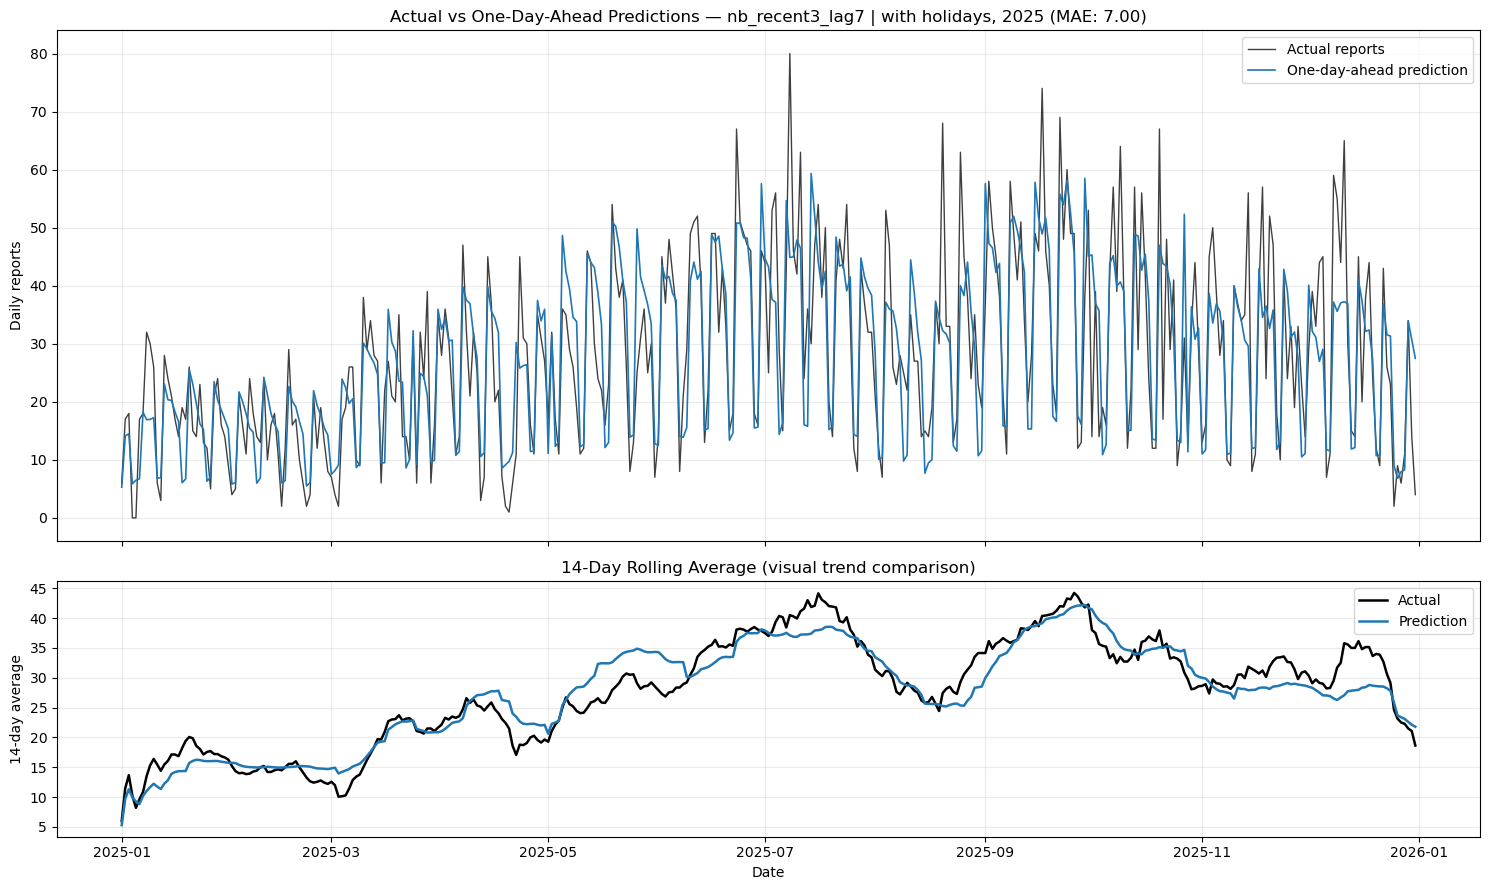

In [38]:
# -----------------------------
# Choose exactly what to plot
# -----------------------------
PLOT_BASE_MODEL = "nb_recent3_lag7"
PLOT_HOLIDAY_VERSION = "with"  # choose: "with" or "without"
PLOT_YEAR = 2025
SMOOTHING_DAYS = 14

HISTORY_AWARE_MODELS = {
    "lag7", "rolling7", "same_weekday_4wk",
    "nb_lag1", "nb_recent3", "nb_lag1_lag7", "nb_4wk",
    "nb_recent3_lag7", "nb_recent3_lag7_no_weekday",
    "nb_recent3_lag7_no_weekday_no_trend"
}

if PLOT_BASE_MODEL in NB_FORMULAS:
    if PLOT_HOLIDAY_VERSION not in {"with", "without"}:
        raise ValueError("PLOT_HOLIDAY_VERSION must be 'with' or 'without'.")
    PLOT_MODEL = (
        f"{PLOT_BASE_MODEL} | {PLOT_HOLIDAY_VERSION} holidays"
    )
else:
    # Holiday versions do not apply to fixed-rule baselines.
    PLOT_MODEL = PLOT_BASE_MODEL

available_plot_models = set(average_results["Model"])
if PLOT_MODEL not in available_plot_models:
    raise ValueError(
        f"{PLOT_MODEL!r} was not tested. Change the plot selection or rerun "
        "the model-testing cell with matching MODELS_TO_TEST/HOLIDAY_MODE settings."
    )

if PLOT_BASE_MODEL not in HISTORY_AWARE_MODELS:
    print("Note: the selected model does not use lagged real observations.")

plot_data = (
    pd.DataFrame(oos_predictions)
    .loc[lambda x: (x["Model"] == PLOT_MODEL) & (x["Test Year"] == PLOT_YEAR)]
    .sort_values("reported")
    .copy()
)

if plot_data.empty:
    raise ValueError(
        f"No predictions found for {PLOT_MODEL!r} in {PLOT_YEAR}. "
        "Run the model-testing cell first and choose a tested model/year."
    )

plot_data["actual_smoothed"] = (
    plot_data["reports"].rolling(SMOOTHING_DAYS, min_periods=1).mean()
)
plot_data["prediction_smoothed"] = (
    plot_data["prediction"].rolling(SMOOTHING_DAYS, min_periods=1).mean()
)
plot_mae = mean_absolute_error(plot_data["reports"], plot_data["prediction"])

fig, axes = plt.subplots(
    2, 1, figsize=(15, 9), sharex=True,
    gridspec_kw={"height_ratios": [2, 1]}
)

axes[0].plot(
    plot_data["reported"], plot_data["reports"],
    label="Actual reports", color="black", linewidth=1.0, alpha=0.75
)
axes[0].plot(
    plot_data["reported"], plot_data["prediction"],
    label="One-day-ahead prediction", color="tab:blue", linewidth=1.2
)
axes[0].set_ylabel("Daily reports")
axes[0].set_title(
    f"Actual vs One-Day-Ahead Predictions — {PLOT_MODEL}, {PLOT_YEAR} "
    f"(MAE: {plot_mae:.2f})"
)
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(
    plot_data["reported"], plot_data["actual_smoothed"],
    label="Actual", color="black", linewidth=1.8
)
axes[1].plot(
    plot_data["reported"], plot_data["prediction_smoothed"],
    label="Prediction", color="tab:blue", linewidth=1.8
)
axes[1].set_xlabel("Date")
axes[1].set_ylabel(f"{SMOOTHING_DAYS}-day average")
axes[1].set_title(f"{SMOOTHING_DAYS}-Day Rolling Average (visual trend comparison)")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


## 6. How to use this notebook

A practical workflow is:

1. Run the notebook from the top once.
2. Set `MODELS_TO_TEST = ["all"]` and `HOLIDAY_MODE = "both"` to compare average MAE/RMSE with and without holidays.
3. Put any subset of model names in `MODELS_TO_TEST` to compare only those models.
4. For residual diagnostics, also set `HOLIDAY_MODE` to either `"with"` or `"without"` so only one fitted variant runs.
5. Keep the holiday term or another feature only if it improves **out-of-sample** performance consistently enough to justify the added complexity.

For the current project, MAE is particularly interpretable: an MAE of 7.6 means the forecast misses the actual daily report count by about 7.6 reports on average.
